In [1]:
import os

In [2]:
!pwd

/Users/abhikchoudhury/Library/CloudStorage/OneDrive-IBM/Badlo/Krish Naik Projects/Kidney_Tumor_Identification_System_Computer_vision/Kidney Tumor Identification System_Abhik/research


In [3]:
os.chdir("../")

In [4]:
!pwd

/Users/abhikchoudhury/Library/CloudStorage/OneDrive-IBM/Badlo/Krish Naik Projects/Kidney_Tumor_Identification_System_Computer_vision/Kidney Tumor Identification System_Abhik


In [5]:
#Now we need to collect MLFLOW tracking URI and credentials from Dagshub.
#First create an account in Dagshub, then import your repository from Github. Get this info.

os.environ["MLFLOW_TRACKING_URI"] = "https://dagshub.com/abhik.gatech/tumor_prediction.mlflow"
os.environ["MLFLOW_TRACKING_USERNAME"] = "abhik.gatech"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "108dbfd674e6fe14ea0f63a4695412231e69d6e5"


Also run this in your terminal which will export your credentials to the environment variable.

export MLFLOW_TRACKING_URI=https://dagshub.com/abhik.gatech/tumor_prediction.mlflow

export MLFLOW_TRACKING_USERNAME=abhik.gatech

export MLFLOW_TRACKING_PASSWORD=108dbfd674e6fe14ea0f63a4695412231e69d6e5 

In [6]:
import tensorflow as tf
#import tf_keras as keras # Import the specific legacy package

In [7]:
#load the model
model = tf.keras.models.load_model("artifacts/training/model.h5")
# Use tf_keras to load your model
#model = keras.models.load_model("artifacts/training/model.h5")

In [ ]:
#Initialize my entity

from dataclasses import dataclass
from pathlib import Path

@dataclass(frozen=True)
class EvaluationConfig:
    path_of_model: Path
    training_data: Path
    all_params: dict  #in earlier notebooks, params were taken separately, now the are taken at once as a dict
    mlflow_uri: str
    params_image_size: list
    params_batch_size: int

#after this cell is run, the code is moved to src/cnnClassifier/entity/configentity.py

In [9]:
from cnnClassifier.constants import *
from cnnClassifier.utils.common import read_yaml, create_directories, save_json

In [ ]:
#Now the configuration manager
#JUST LIKE in the previous notebook, we are importing the params.yaml and config.yaml path from the cnnclassifier/constants folder.

class ConfigurationManager:
    def __init__(
        self, 
        config_filepath = CONFIG_FILE_PATH,
        params_filepath = PARAMS_FILE_PATH):
        self.config = read_yaml(config_filepath) #all the parameters from config.yaml are getting stored in config variable
        self.params = read_yaml(params_filepath) #all the parameters from params.yaml are getting stored in params variable
        create_directories([self.config.artifacts_root])

    
    def get_evaluation_config(self) -> EvaluationConfig:
        eval_config = EvaluationConfig(
            path_of_model="artifacts/training/model.h5",
            training_data="artifacts/data_ingestion/kidney-ct-scan-image",
            mlflow_uri="https://dagshub.com/abhik.gatech/tumor_prediction.mlflow",
            all_params=self.params, #for experiment tracking using ML Flow, we need all parameters there.
            params_image_size=self.params.IMAGE_SIZE,
            params_batch_size=self.params.BATCH_SIZE
        )
        return eval_config
    
#after this cell is run, the code is moved to src/cnnClassifier/config/configuration.py

In [11]:
os.environ['TF_USE_LEGACY_KERAS'] = '1'
import tensorflow as tf
from pathlib import Path
import mlflow
import mlflow.keras
from urllib.parse import urlparse

In [ ]:
class Evaluation:
    def __init__(self, config: EvaluationConfig):
        self.config = config

    #the same train_valid_generator function which we created in the model training notebook. Pickup the datatset and prepare the testing data. 
    def _valid_generator(self):

        datagenerator_kwargs = dict(
            rescale = 1./255,
            validation_split=0.30
        )

        dataflow_kwargs = dict(
            target_size=self.config.params_image_size[:-1],
            batch_size=self.config.params_batch_size,
            interpolation="bilinear"
        )

        valid_datagenerator = tf.keras.preprocessing.image.ImageDataGenerator(
            **datagenerator_kwargs
        )

        self.valid_generator = valid_datagenerator.flow_from_directory(
            directory=self.config.training_data,
            subset="validation",
            shuffle=False,
            **dataflow_kwargs
        )

    
    @staticmethod
    def load_model(path: Path) -> tf.keras.Model:
        return tf.keras.models.load_model(path)
    

    def evaluation(self):
        self.model = self.load_model(self.config.path_of_model)
        self._valid_generator()
        #self.score = self.model.evaluate(self.valid_generator)
        self.score = model.evaluate(self.valid_generator)
        self.save_score()

    
    def save_score(self):
        scores = {"loss": self.score[0], "accuracy": self.score[1]}
        save_json(path=Path("scores.json"), data=scores)

    

    def log_into_mlflow(self):
        mlflow.set_registry_uri(self.config.mlflow_uri)
        tracking_url_type_store = urlparse(mlflow.get_tracking_uri()).scheme
        
        with mlflow.start_run():
            mlflow.log_params(self.config.all_params)
            mlflow.log_metrics(
                {"loss": self.score[0], "accuracy": self.score[1]}
            )
            # Model registry does not work with file store
            if tracking_url_type_store != "file":

                # Register the model
                # There are other ways to use the Model Registry, which depends on the use case,
                # please refer to the doc for more information:
                # https://mlflow.org/docs/latest/model-registry.html#api-workflow
                mlflow.keras.log_model(self.model, "model", registered_model_name="VGG16Model")
            else:
                mlflow.keras.log_model(self.model, "model")

 #after this cell is run, the code is moved to src/cnnClassifier/components/model_evaluation_mlflow.py   

In [15]:
import tensorflow as tf
import keras

# Patch the missing __version__ that MLflow looks for
if not hasattr(tf.keras, '__version__'):
    tf.keras.__version__ = keras.__version__

In [ ]:
try:
    config = ConfigurationManager()
    eval_config = config.get_evaluation_config()
    evaluation = Evaluation(eval_config)
    evaluation.evaluation()
    evaluation.log_into_mlflow()

except Exception as e:
   raise e

#after this cell is run, the code is moved to src/cnnClassifier/pipeline/stage_04_model_evaluation.py

[2026-05-07 18:38:04,084: INFO: common: yaml file: config/config.yaml loaded successfully]
[2026-05-07 18:38:04,091: INFO: common: yaml file: params.yaml loaded successfully]
[2026-05-07 18:38:04,092: INFO: common: created directory at: artifacts]
Found 139 images belonging to 2 classes.
9/9 [==============================] - 21s 2s/step - loss: 29.4595 - accuracy: 0.4820
[2026-05-07 18:38:25,550: INFO: common: json file saved at: scores.json]


2026/05/07 18:38:26 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


INFO:tensorflow:Assets written to: /var/folders/h_/hf4fvq0j29139m0cdlms8lg80000gn/T/tmprn_8cgf7/model/data/model/assets
[2026-05-07 18:38:27,297: INFO: builder_impl: Assets written to: /var/folders/h_/hf4fvq0j29139m0cdlms8lg80000gn/T/tmprn_8cgf7/model/data/model/assets]


2026/05/07 18:38:32 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /var/folders/h_/hf4fvq0j29139m0cdlms8lg80000gn/T/tmprn_8cgf7/model, flavor: tensorflow), fall back to return ['tensorflow==2.13.0']. Set logging level to DEBUG to see the full traceback.
/opt/anaconda3/envs/kidney/lib/python3.8/site-packages/_distutils_hack/__init__.py:31: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(
Registered model 'VGG16Model' already exists. Creating a new version of this model...
2026/05/07 18:38:53 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation.                     Model name: VGG16Model, version 6
Created version '6' of model 'VGG16Model'.


### Explanation of the whole code

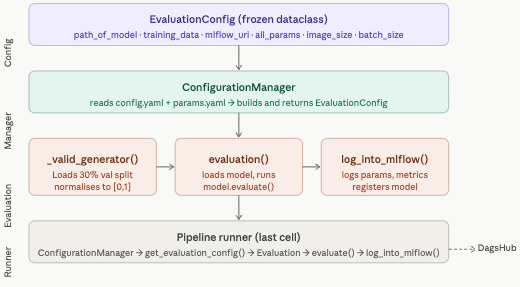

Layer 1 — The Config Entity (EvaluationConfig)

The @dataclass(frozen=True) decorator is the key design choice. frozen=True makes it immutable — nobody can accidentally overwrite config.mlflow_uri mid-run. This is a standard pattern in MLOps pipelines to prevent stateful bugs.

Layer 2 — The ConfigurationManager
This class acts as the single source of truth for all runtime configuration. It reads two YAML files: config.yaml (paths, URIs — infrastructure concerns) and params.yaml (hyperparameters — experiment concerns). Separating these two is intentional and important. It means you can change a hyperparameter without touching infra config, and vice versa.
The get_evaluation_config() method assembles and returns the frozen entity. 

Notice all_params=self.params — rather than passing individual params, the entire params.yaml dict is passed to MLflow, so every experiment run is fully reproducible. The practical upshot: all_params is a safety net. Even if someone adds a new parameter to params.yaml tomorrow, it automatically gets logged without anyone having to touch log_into_mlflow(). The individual params like params_image_size are pulled out separately only because the data generator needs them as direct Python variables to function — MLflow doesn't need that, it just needs the whole dict for record-keeping.

Layer 3 — The Evaluation Class
This is the core, and it has three methods worth understanding separately:
_valid_generator() — the leading underscore signals it's a private method, only called internally. It creates a validation data generator using 30% of the training directory as a validation split. rescale=1./255 normalises pixel values from [0, 255] to [0, 1], which neural networks require. shuffle=False is critical for evaluation — you never shuffle test/val data because it would make metric comparisons across runs meaningless.

evaluation() — loads the saved .h5 model and calls model.evaluate() on the validation generator. This computes loss and accuracy without updating any weights. Note there's actually a subtle bug here: line 238 uses the global model variable instead of self.model. This works only because the global was set earlier in the notebook, but it's fragile — in production code this should always be self.model.evaluate(...).

log_into_mlflow() — this is the MLflow heart of the notebook. Three things happen inside with mlflow.start_run():

mlflow.log_params(self.config.all_params) — logs every hyperparameter as key-value metadata on the run

mlflow.log_metrics({"loss": ..., "accuracy": ...}) — logs the evaluation numbers

mlflow.keras.log_model(...) — serialises and uploads the actual model artifact, and optionally registers it in the Model Registry

The urlparse check for "file" is an MLflow quirk: the Model Registry (the versioning system) only works with remote tracking servers, not local file-based ones. If you're running MLflow locally, it skips registration.


Layer 4 — The Pipeline Runner
The last cell is just orchestration — create the config, create the evaluation object, call its methods in order. This separation means you can test each layer in isolation, which is exactly what senior ML engineers do.


The MLflow tracking setup:
os.environ["MLFLOW_TRACKING_URI"] = "https://dagshub.com/..."
DagsHub is acting as a hosted MLflow tracking server. In production teams this is usually replaced by a self-hosted MLflow server or a managed service like Azure ML or SageMaker Experiments. The credential injection via environment variables (rather than hardcoding) is correct practice, though for a real project these would live in a .env file or secrets manager, not directly in a notebook.



#### Just a refresher of how Self works in a class

class Dog:
    def __init__(self, name):
        # self.name saves the name to this specific dog
        self.name = name 

    def bark(self):
        # self lets the bark method know which dog is barking
        print(f"{self.name} says woof!")

""" Create two different objects """
dog1 = Dog("Buddy")
dog2 = Dog("Lucy")

dog1.bark()  # Buddy says woof!
dog2.bark()  # Lucy says woof!
